In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
import seaborn as sns
import yfinance as yf
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  1 of 1 completed


Text(0, 0.5, 'Price')

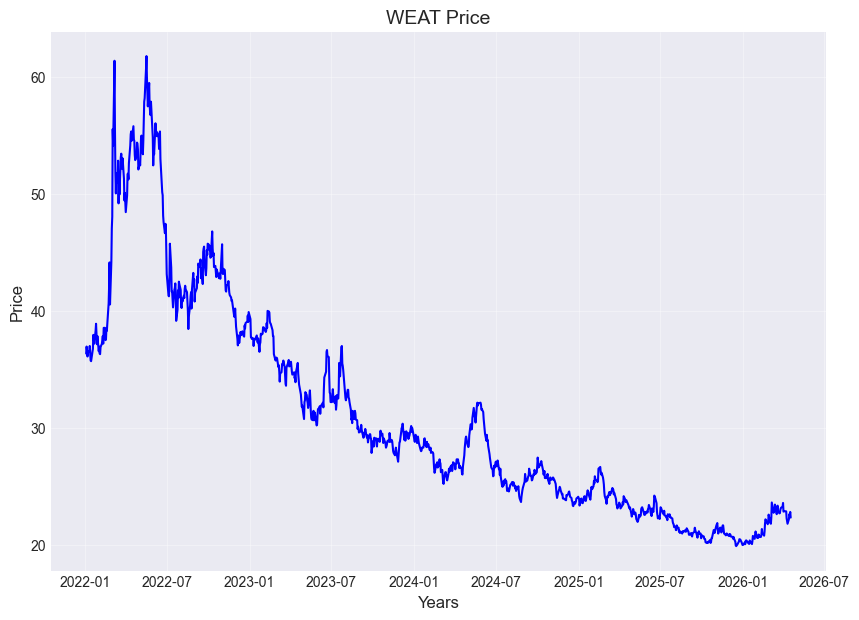

In [41]:
ticker = "WEAT"

data = yf.download(ticker, start="2022-01-01", interval="1d",auto_adjust=False,multi_level_index=False)

# Drop the missing values
data = data.dropna()

# Rolling Window
rolling_window = int(len(data)*0.70)

# Plot the series
plt.figure(figsize=(10, 7))
plt.plot(data['Adj Close'], 'blue')
plt.title("WEAT Price", fontsize=14)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Price", fontsize=12)


In [42]:
# Import ARIMA
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)

# Train autoregressive model of order 1
model_fit = ARIMA(data['Adj Close'][:rolling_window], order=(1, 0, 0), exog=None).fit()
round(model_fit.params,2)

const     33.33
ar.L1      0.99
sigma2     0.84
dtype: float64

In [44]:
# Function to predict the price of 1 day
def predict_price_AR(train_data):
    # Define model
    model = ARIMA(train_data, order=(1, 0, 0))

    # Fit the model
    model_fit = model.fit()

    # Make forecast
    forecast_results = model_fit.forecast()

    return forecast_results[0]

In [45]:
# Predict the price using `predict_price_AR` function
data['predicted_price'] = data['Adj Close'].rolling(rolling_window).apply(predict_price_AR)
# Shift the predicted price by 1 period
data['predicted_price'] = data['predicted_price'].shift(1)

KeyError: 0

In [46]:
# Import libraries
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from math import sqrt

def model_performance(observed, predicted):


    """This function will print the Mean Absolute Error, Mean Squared Error,
    Root Mean Squared Error and Mean Absolute Percentage Error.
    This function will also display the residula plot and the ACF.
    """

    # Mean Absolute Error
    mae = mean_absolute_error(observed, predicted)
    print('The Mean Absolute Error is %.2f' % mae)

    # Mean Squared Error
    mse = mean_squared_error(observed, predicted)
    print('The Mean Squared Error is %.2f' % mse)

    # Root Mean Squared Error
    rmse = sqrt(mean_squared_error(observed, predicted))
    print('The Root Mean Squared Error is %.2f' % rmse)

    # Mean Absolute Percentage Error
    mape = 100 * ((observed-predicted)/observed).abs().mean()
    print('The Mean Absolute Percentage Error is %.2f' % mape)

    # Residuals
    residuals = observed - predicted
    labels = observed.index
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 11))

    # Plot residual
    observed.plot(ax=ax1, color='purple')
    predicted.plot(ax=ax1, color='green')
    ax1.set_ylabel('Price')
    ax1.set_title('Predicted Vs. Observed')

    # Plot residual
    ax2.fill_between(residuals.index, residuals.values, color='red')
    ax2.set_ylabel('Error')
    ax2.set_xlabel('Date')
    ax2.set_title('Residual')
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    ax2.xaxis.set_minor_formatter(mdates.DateFormatter("%d-%m-%Y"))
    _=plt.xticks(rotation=45)

    # Autocorrelation plot of residuals
    plot_pacf(residuals, ax=ax3, color='blue')
    ax3.set_xlabel('Lags')
    ax3.set_ylabel('Partial Autocorrelation')
    ax3.set_title('Partial Autocorrelation of Residuals')

    plt.tight_layout()
    plt.show()

# Call `model_performance` to evaluate the performance of the model
model_performance(data['Adj Close'].iloc[rolling_window:],
                  data['predicted_price'].iloc[rolling_window:])

KeyError: 'predicted_price'